In [1]:
import os
import sys
import json
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
plt.style.use('ggplot')

# Configuration & Directory Setup
RESULTS_DIR = Path("./research_output")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Setup local logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(RESULTS_DIR / "experiment.log"),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)
logger.info("Environment initialized. Results will be saved to: %s", RESULTS_DIR)

2026-01-22 17:13:34,914 - INFO - Environment initialized. Results will be saved to: research_output


In [2]:
# Publication-ready settings for research papers
plt.rcParams.update({
    # Figure properties - optimized for journal columns
    'figure.figsize': (3.5, 2.625),  # Single column width (3.5") with 4:3 aspect ratio
    'figure.dpi': 600,  # Higher DPI for publication quality
    'savefig.dpi': 600,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,  # Minimal padding
    
    # Font properties - LaTeX-style typography
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'font.size': 8,  # Smaller for fitting in columns
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'legend.title_fontsize': 8,
    
    # Use LaTeX for text rendering (if available)
    'text.usetex': False,  # Set to True if you have LaTeX installed
    'mathtext.fontset': 'dejavuserif',  # Match serif font for math
    
    # Line and marker properties
    'lines.linewidth': 1.2,
    'lines.markersize': 4,
    'lines.markeredgewidth': 0.5,
    'patch.linewidth': 0.5,
    
    # Axes properties
    'axes.linewidth': 0.8,
    'axes.grid': False,  # Turn off by default, enable selectively
    'axes.labelpad': 4,
    'axes.titlepad': 6,
    'axes.xmargin': 0.02,  # Reduce margins
    'axes.ymargin': 0.02,
    
    # Grid properties (when enabled)
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'grid.color': 'gray',
    
    # Remove top and right spines for cleaner look
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    
    # Tick properties
    'xtick.major.size': 3,
    'xtick.minor.size': 2,
    'ytick.major.size': 3,
    'ytick.minor.size': 2,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    
    # Legend properties
    'legend.frameon': False,
    'legend.loc': 'best',
    'legend.borderaxespad': 0.5,
    'legend.columnspacing': 1,
    'legend.handlelength': 1.5,
    'legend.handleheight': 0.7,
    
    # Figure layout
    'figure.autolayout': False,
    'figure.constrained_layout.use': True,  # Better than tight_layout
    'figure.constrained_layout.h_pad': 0.04,
    'figure.constrained_layout.w_pad': 0.04,
})

# Define common figure sizes for different journal formats
FIGURE_SIZES = {
    'single_column': (3.5, 2.625),      # Standard single column (3.5" wide)
    'double_column': (7.0, 5.25),       # Standard double column (7.0" wide)
    'single_column_tall': (3.5, 4.5),   # For vertical plots
    'double_column_wide': (7.0, 3.0),   # For wide horizontal plots
}

# Publication-quality color schemes (colorblind-friendly)
COLORS = {
    'qualitative': ['#0173B2', '#DE8F05', '#029E73', '#CC78BC', 
                    '#CA9161', '#949494', '#ECE133'],
    'sequential_blue': ['#F0F9FF', '#C9EBFF', '#90D5FF', '#4FB3E8', 
                        '#0173B2', '#014E7A'],
    'diverging': ['#364B9A', '#4A7BB7', '#6EA6CD', '#98CAE1', 
                  '#C2E4EF', '#EAECCC', '#FEDA8B', '#FDB366', 
                  '#F67E4B', '#DD3D2D', '#A50026'],
}
def set_figure_size(size_name='single_column'):
    """Helper function to set figure size"""
    plt.rcParams['figure.figsize'] = FIGURE_SIZES.get(size_name, FIGURE_SIZES['single_column'])

# Example usage:
# set_figure_size('double_column')
# fig, ax = plt.subplots()
# ax.plot(x, y, color=COLORS['qualitative'][0], label='Data')
# ax.set_xlabel('X-axis label')
# ax.set_ylabel('Y-axis label')
# ax.legend()
# plt.savefig('figure.pdf')

In [3]:
MLFLOW_ENABLED = True
if MLFLOW_ENABLED:
    import mlflow
    from mlflow.tensorflow import autolog
    
    def get_next_run_number(experiment_name, tracking_uri):
        """Get next run number for the experiment"""
        try:
            from mlflow.tracking import MlflowClient
            client = MlflowClient(tracking_uri)
            experiment = client.get_experiment_by_name(experiment_name)
            
            if experiment:
                runs = client.search_runs(experiment_ids=[experiment.experiment_id])
                return len(runs)+1
        except:
            pass
        return 1
    
    experiment_name = Path().resolve().name
    tracking_uri = "http://localhost:5000/"
    run_number = get_next_run_number(experiment_name, tracking_uri)
    run_name = "run" + str(run_number)
    mlflow.set_tracking_uri(tracking_uri)
    mlflow.set_experiment(experiment_name)
    mlflow.start_run(run_name=run_name,log_system_metrics=True)
    autolog(log_models=True, log_input_examples=True, log_model_signatures=True)
    print(f"MLflow run started | experiment={experiment_name} | run_name={run_name}")

2026-01-22 17:13:38.579197: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/srirama/sr_proj/tf-venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
2026/01/22 17:13:43 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/01/22 17:13:43 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


MLflow run started | experiment=2-rnn | run_name=run3


In [4]:
# Replace these paths with your actual data locations
TRAIN_PATH = "/home/srirama/sr_proj/ECGHeartbeatCategorization/data/1/mitbih_train.csv"
TEST_PATH = "/home/srirama/sr_proj/ECGHeartbeatCategorization/data/1/mitbih_test.csv"

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPool1D, Flatten, Dense, Dropout, BatchNormalization,Input,MaxPooling1D,GlobalAveragePooling1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import SimpleRNN, Embedding

print("Tensorflow version :",tf.__version__)
print("Avaiable devices :",tf.config.get_visible_devices())

Tensorflow version : 2.20.0
Avaiable devices : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# Load Data
from IPython.display import display
train_df = pd.read_csv(TRAIN_PATH, header=None)
val_df = pd.read_csv(TEST_PATH, header=None)
display(train_df.sample(3))
display(val_df.sample(3))
print(f"Train Data shape : {train_df.shape} | Test Data Shape : {val_df.shape}")

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
43185,1.0,0.981982,0.792793,0.522523,0.315315,0.229730,0.207207,0.198198,0.180180,0.202703,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34888,1.0,0.813187,0.386813,0.193407,0.085714,0.043956,0.041758,0.054945,0.112088,0.265934,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41186,1.0,0.449123,0.007018,0.101754,0.119298,0.108772,0.112281,0.115789,0.087719,0.091228,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
6140,1.0,0.736544,0.586402,0.283286,0.169972,0.062323,0.033994,0.025496,0.019830,0.019830,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19235,1.0,0.987790,0.826618,0.487179,0.161172,0.118437,0.142857,0.103785,0.078144,0.081807,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2739,1.0,0.774481,0.551929,0.272997,0.181009,0.071217,0.029674,0.011869,0.014837,0.020772,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Train Data shape : (87554, 188) | Test Data Shape : (21892, 188)


In [7]:
# Separate features (X) and labels (y)
X_train_raw = train_df.iloc[:, :-1].values
y_train_raw = train_df.iloc[:, -1].values
X_val_raw = val_df.iloc[:, :-1].values
y_val_raw = val_df.iloc[:, -1].values

In [8]:
# Preprocessing
NUM_CLASSES = 5 
CLASS_NAMES = ['N (0) - Normal', 'S (1) - SVEB', 'V (2) - VEB', 'F (3) - Fusion', 'Q (4) - Unknown']
INPUT_LENGTH  = X_train_raw.shape[1]
# One-Hot Encode Output Labels (Needed for categorical_crossentropy)
y_train_cat = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_val_cat = to_categorical(y_val_raw, num_classes=NUM_CLASSES)

In [9]:
print(f"Original Training data shape: {X_train_raw.shape}")
print(f"Class distribution before balancing:\n{train_df.iloc[:, -1].value_counts(normalize=True).sort_index()}")
print(f"Number of sensor inputs : {INPUT_LENGTH} and Output Categories : {NUM_CLASSES}")

Original Training data shape: (87554, 187)
Class distribution before balancing:
187
0.0    0.827729
1.0    0.025390
2.0    0.066108
3.0    0.007321
4.0    0.073452
Name: proportion, dtype: float64
Number of sensor inputs : 187 and Output Categories : 5


In [10]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_raw),
    y=y_train_raw
)
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.24162492583240192), 1: np.float64(7.877103013945119), 2: np.float64(3.0253628196268143), 3: np.float64(27.317940717628705), 4: np.float64(2.7228735810915876)}


In [11]:
from sklearn.model_selection import train_test_split
# Split training data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(
    X_train_raw, y_train_cat, 
    test_size=0.3, random_state=42, 
    stratify=y_train_cat
) 

Because Timseries models expects:
- A sequence = 187 timesteps
- A channel per timestep = 1 feature per time instant
If you had multi-channel signals (like accelerometers with x/y/z axes), it would be (187, 3).

In [12]:
# Reshape for Timseries models: (batch, timesteps, channels)
X_train = X_train.reshape(-1, INPUT_LENGTH, 1)
X_test  = X_test.reshape(-1, INPUT_LENGTH, 1)
X_val  = X_val_raw.reshape(-1, INPUT_LENGTH, 1)
print(X_train.shape)   # (?, 187, 1)
print(y_train.shape)   # (?, 5)

(61287, 187, 1)
(61287, 5)


In [13]:
timesteps  = INPUT_LENGTH
channel = 1
model = Sequential()
model.add(Input(shape=(timesteps,channel), dtype='int32'))
model.add(SimpleRNN(256, return_sequences=False))
model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(16, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(4, activation="relu"))
model.add(Dense(NUM_CLASSES, activation="softmax"))
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)
model.summary()

I0000 00:00:1769102035.790652   64791 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 256)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,301 (333.21 KB)

 Trainable params: 85,301 (333.21 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger

# Callbacks for reproducibility and artifact saving
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint(RESULTS_DIR / "best_rnn_model.keras", save_best_only=True),
    CSVLogger(RESULTS_DIR / "training_history.csv")
]

logger.info("Starting model training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, # Increased for research validity
    batch_size=512,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

2026-01-22 17:13:57,708 - INFO - Starting model training...


Epoch 1/100


2026-01-22 17:14:02.411315: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ee044008050 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-22 17:14:02.411370: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2026-01-22 17:14:02.525812: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-22 17:14:03.155526: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-01-22 17:14:03.277581: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-22 17:14:06.834094: I e

119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.4937 - loss: 1.5934

2026-01-22 17:14:24.452206: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-22 17:14:24.452318: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-22 17:14:24.452417: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-22 17:14:24.904296: I external/l

120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.4940 - loss: 1.5936

2026-01-22 17:14:38.067603: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-22 17:14:38.712258: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_8', 8 bytes spill stores, 8 bytes spill loads

2026-01-22 17:14:39.902386: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_243', 8 bytes spill stores, 8 bytes spill loads

2026-01-22 17:14:40.619954: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_243', 352 bytes spil

2026-01-22 17:14:43,237 - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
120/120 ━━━━━━━━━━━━━━━━━━━━ 44s 258ms/step - accuracy: 0.5345 - loss: 1.6106 - val_accuracy: 0.8277 - val_loss: 1.6066
Epoch 2/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 13s 109ms/step - accuracy: 0.5260 - loss: 1.6097 - val_accuracy: 0.0734 - val_loss: 1.6103
Epoch 3/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.0208 - loss: 1.6097 - val_accuracy: 0.0254 - val_loss: 1.6106
Epoch 4/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.0725 - loss: 1.6097 - val_accuracy: 0.0734 - val_loss: 1.6071
Epoch 5/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.1948 - loss: 1.6097 - val_accuracy: 0.0661 - val_loss: 1.6102
Epoch 6/100
120/120 ━━━━━━━━━━━━━━━━━━

2026/01/22 17:16:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/22 17:16:42 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/srirama/sr_proj/tf-venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 17 variables whereas the saved optimizer has 32 variables. "


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [15]:
# Generate predictions for all evaluation steps
y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
class_names = ['Normal', 'SVEB', 'VEB', 'Fusion', 'Unknown']

2026-01-22 17:17:49.910945: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-22 17:17:51.394744: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_179', 16 bytes spill stores, 16 bytes spill loads



685/685 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step


/tmp/ipykernel_64791/1083166279.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


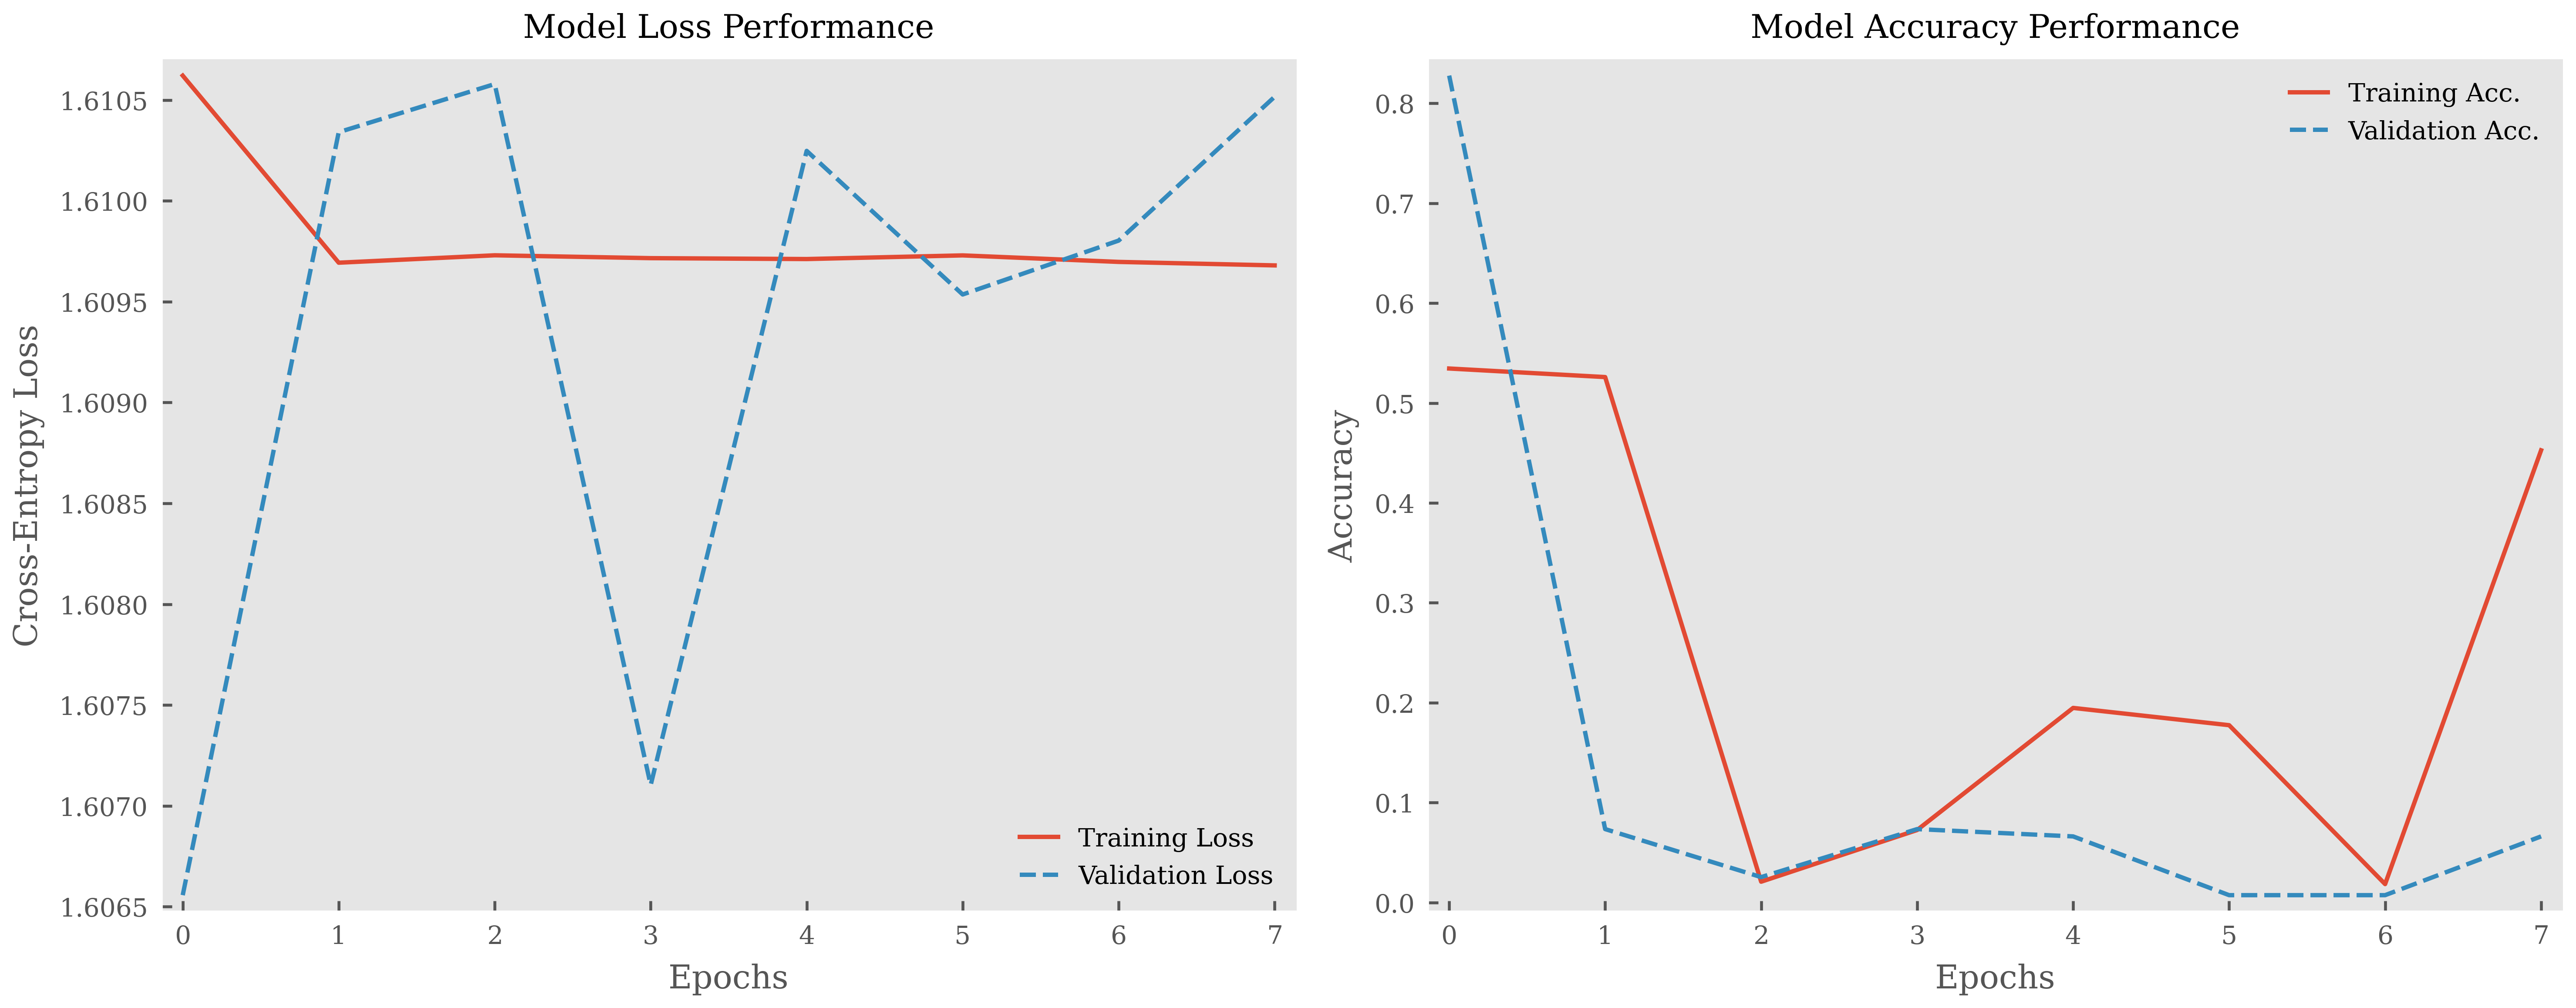

In [16]:
def plot_learning_curves(history, save_path = RESULTS_DIR / "learning_curves.pdf"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Loss Plot
    ax1.plot(history.history['loss'], label='Training Loss', linestyle='-')
    ax1.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
    ax1.set_title('Model Loss Performance')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.legend()

    # Accuracy Plot
    ax2.plot(history.history['accuracy'], label='Training Acc.', linestyle='-')
    ax2.plot(history.history['val_accuracy'], label='Validation Acc.', linestyle='--')
    ax2.set_title('Model Accuracy Performance')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

plot_learning_curves(history)

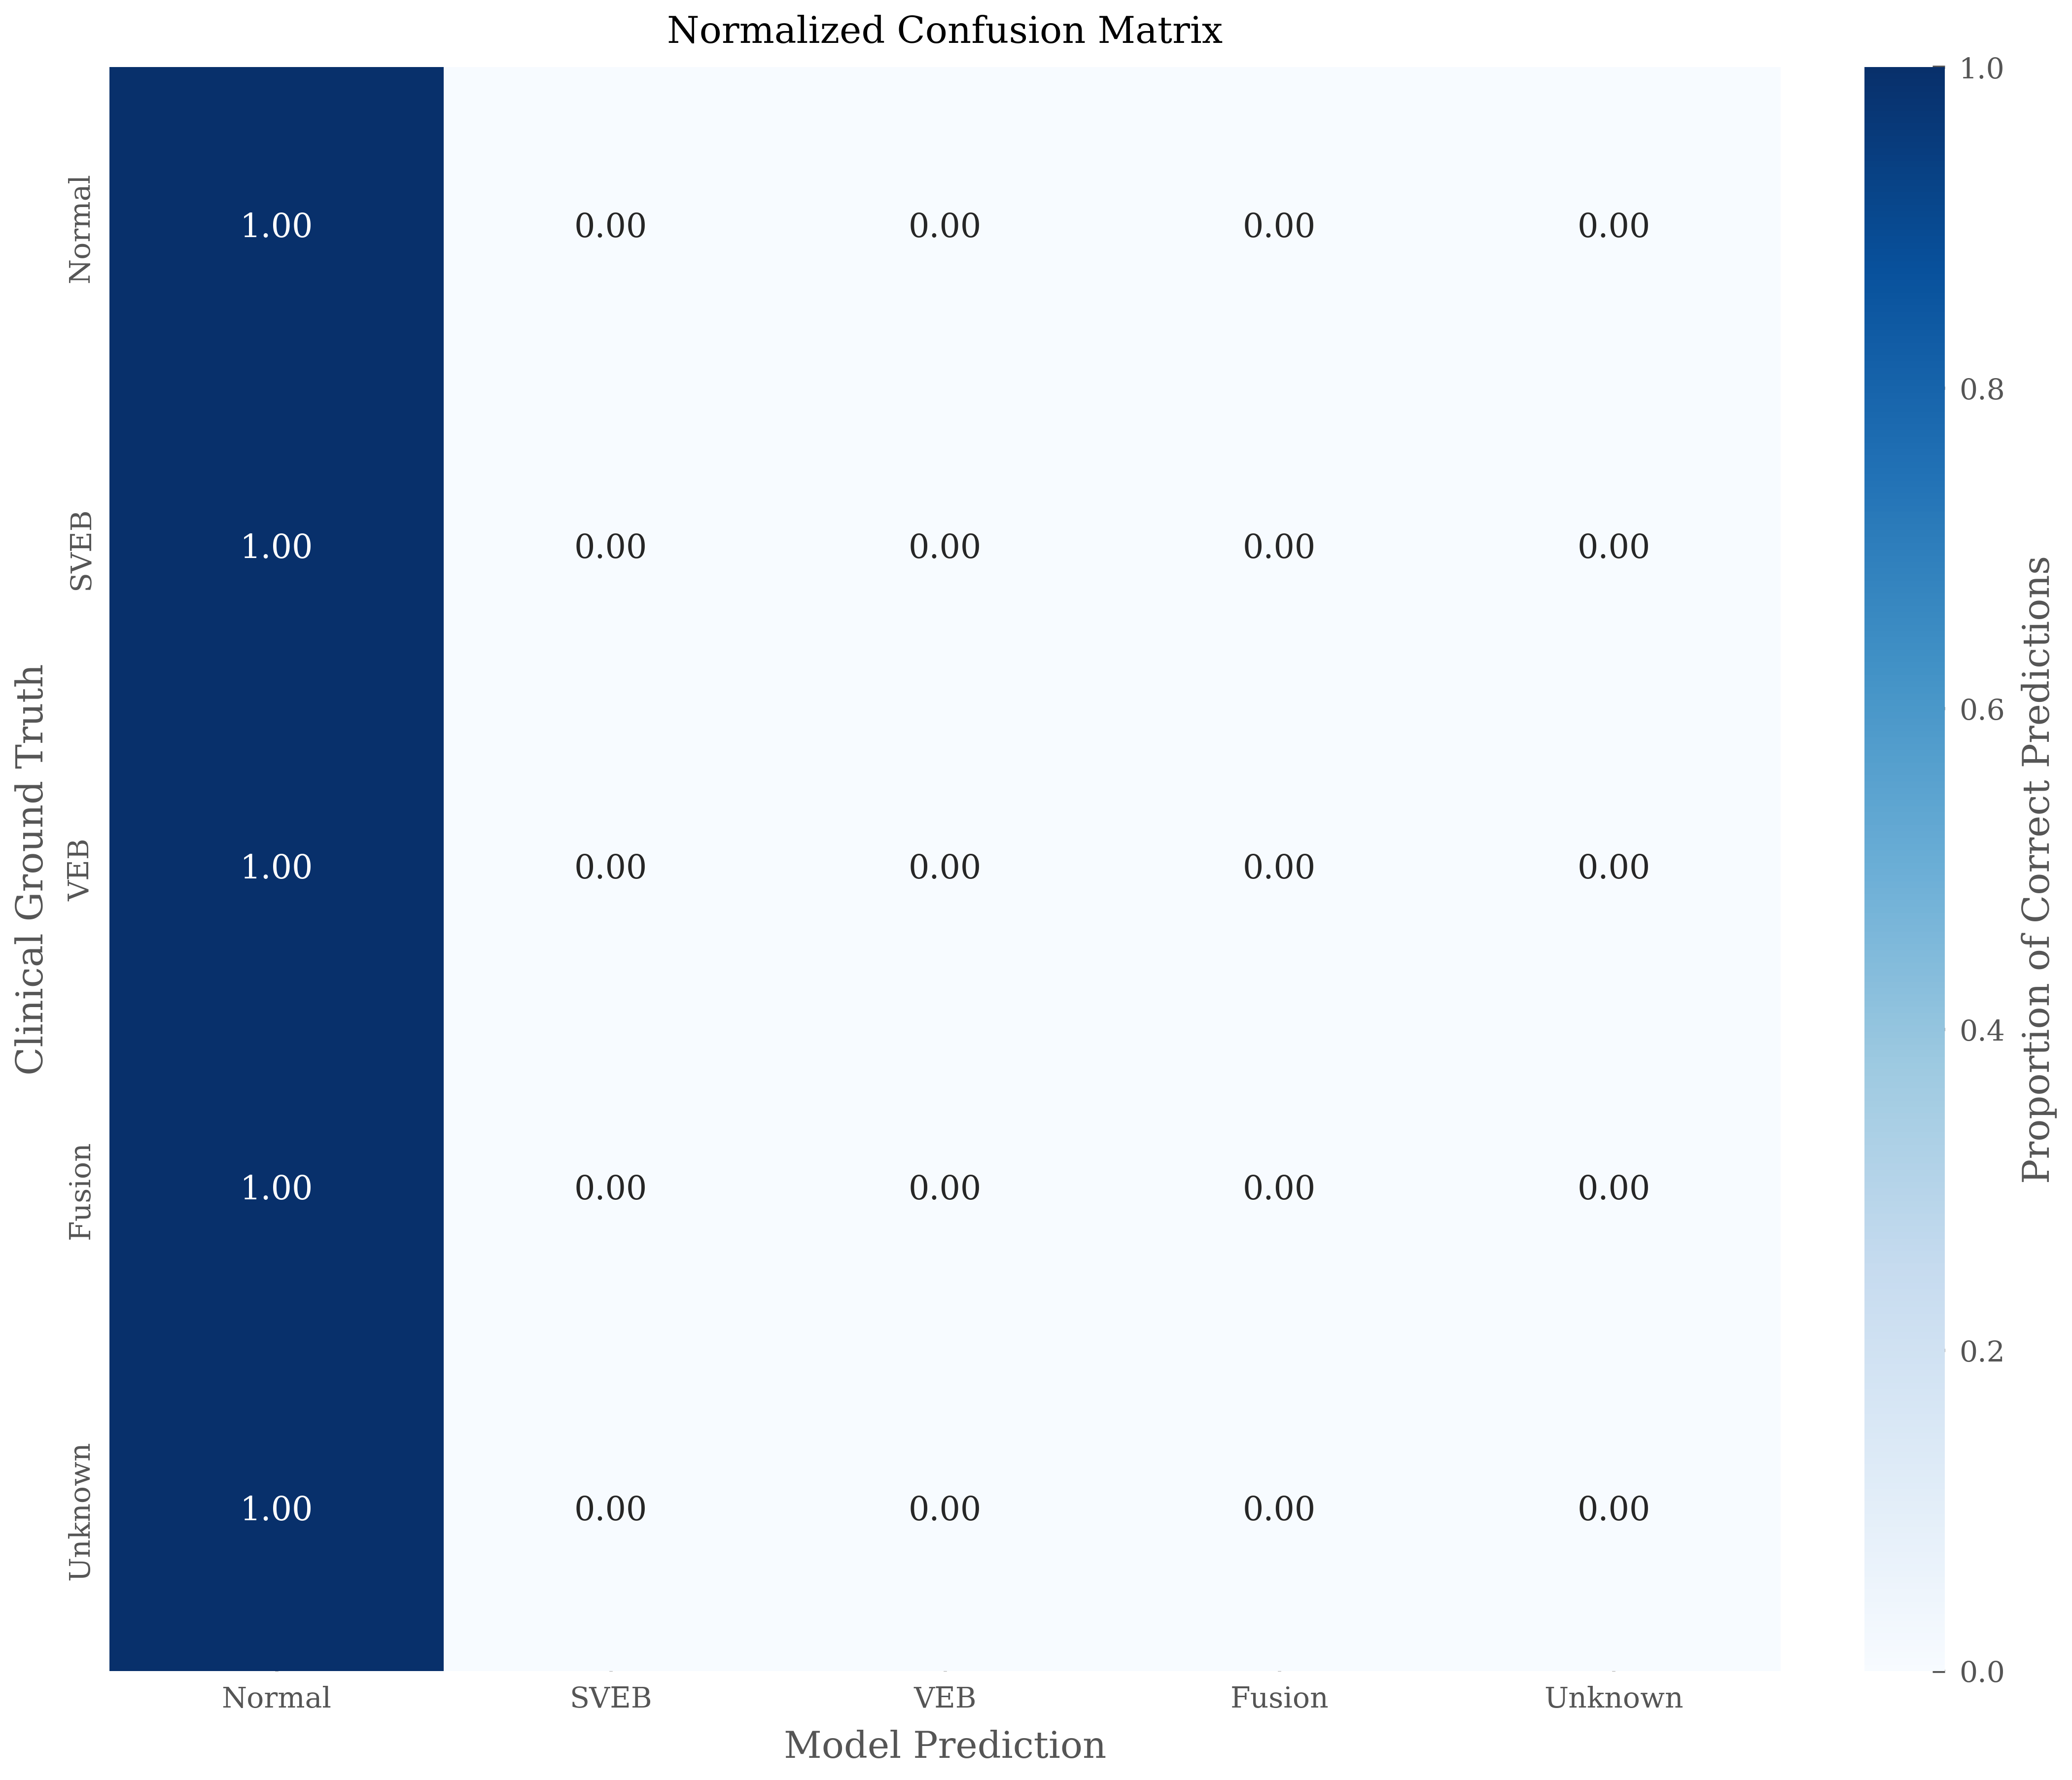

In [17]:
import pandas as pd
from tabulate import tabulate
from sklearn.metrics import classification_report,confusion_matrix,auc,roc_curve

def plot_confusion_matrix(y_true, y_pred, classes, save_path=RESULTS_DIR / "confusion_matrix.pdf"):
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Proportion of Correct Predictions'})

    plt.title('Normalized Confusion Matrix')
    plt.ylabel('Clinical Ground Truth')
    plt.xlabel('Model Prediction')

    plt.savefig(save_path)
    plt.show()

plot_confusion_matrix(y_val_raw, y_pred, class_names)

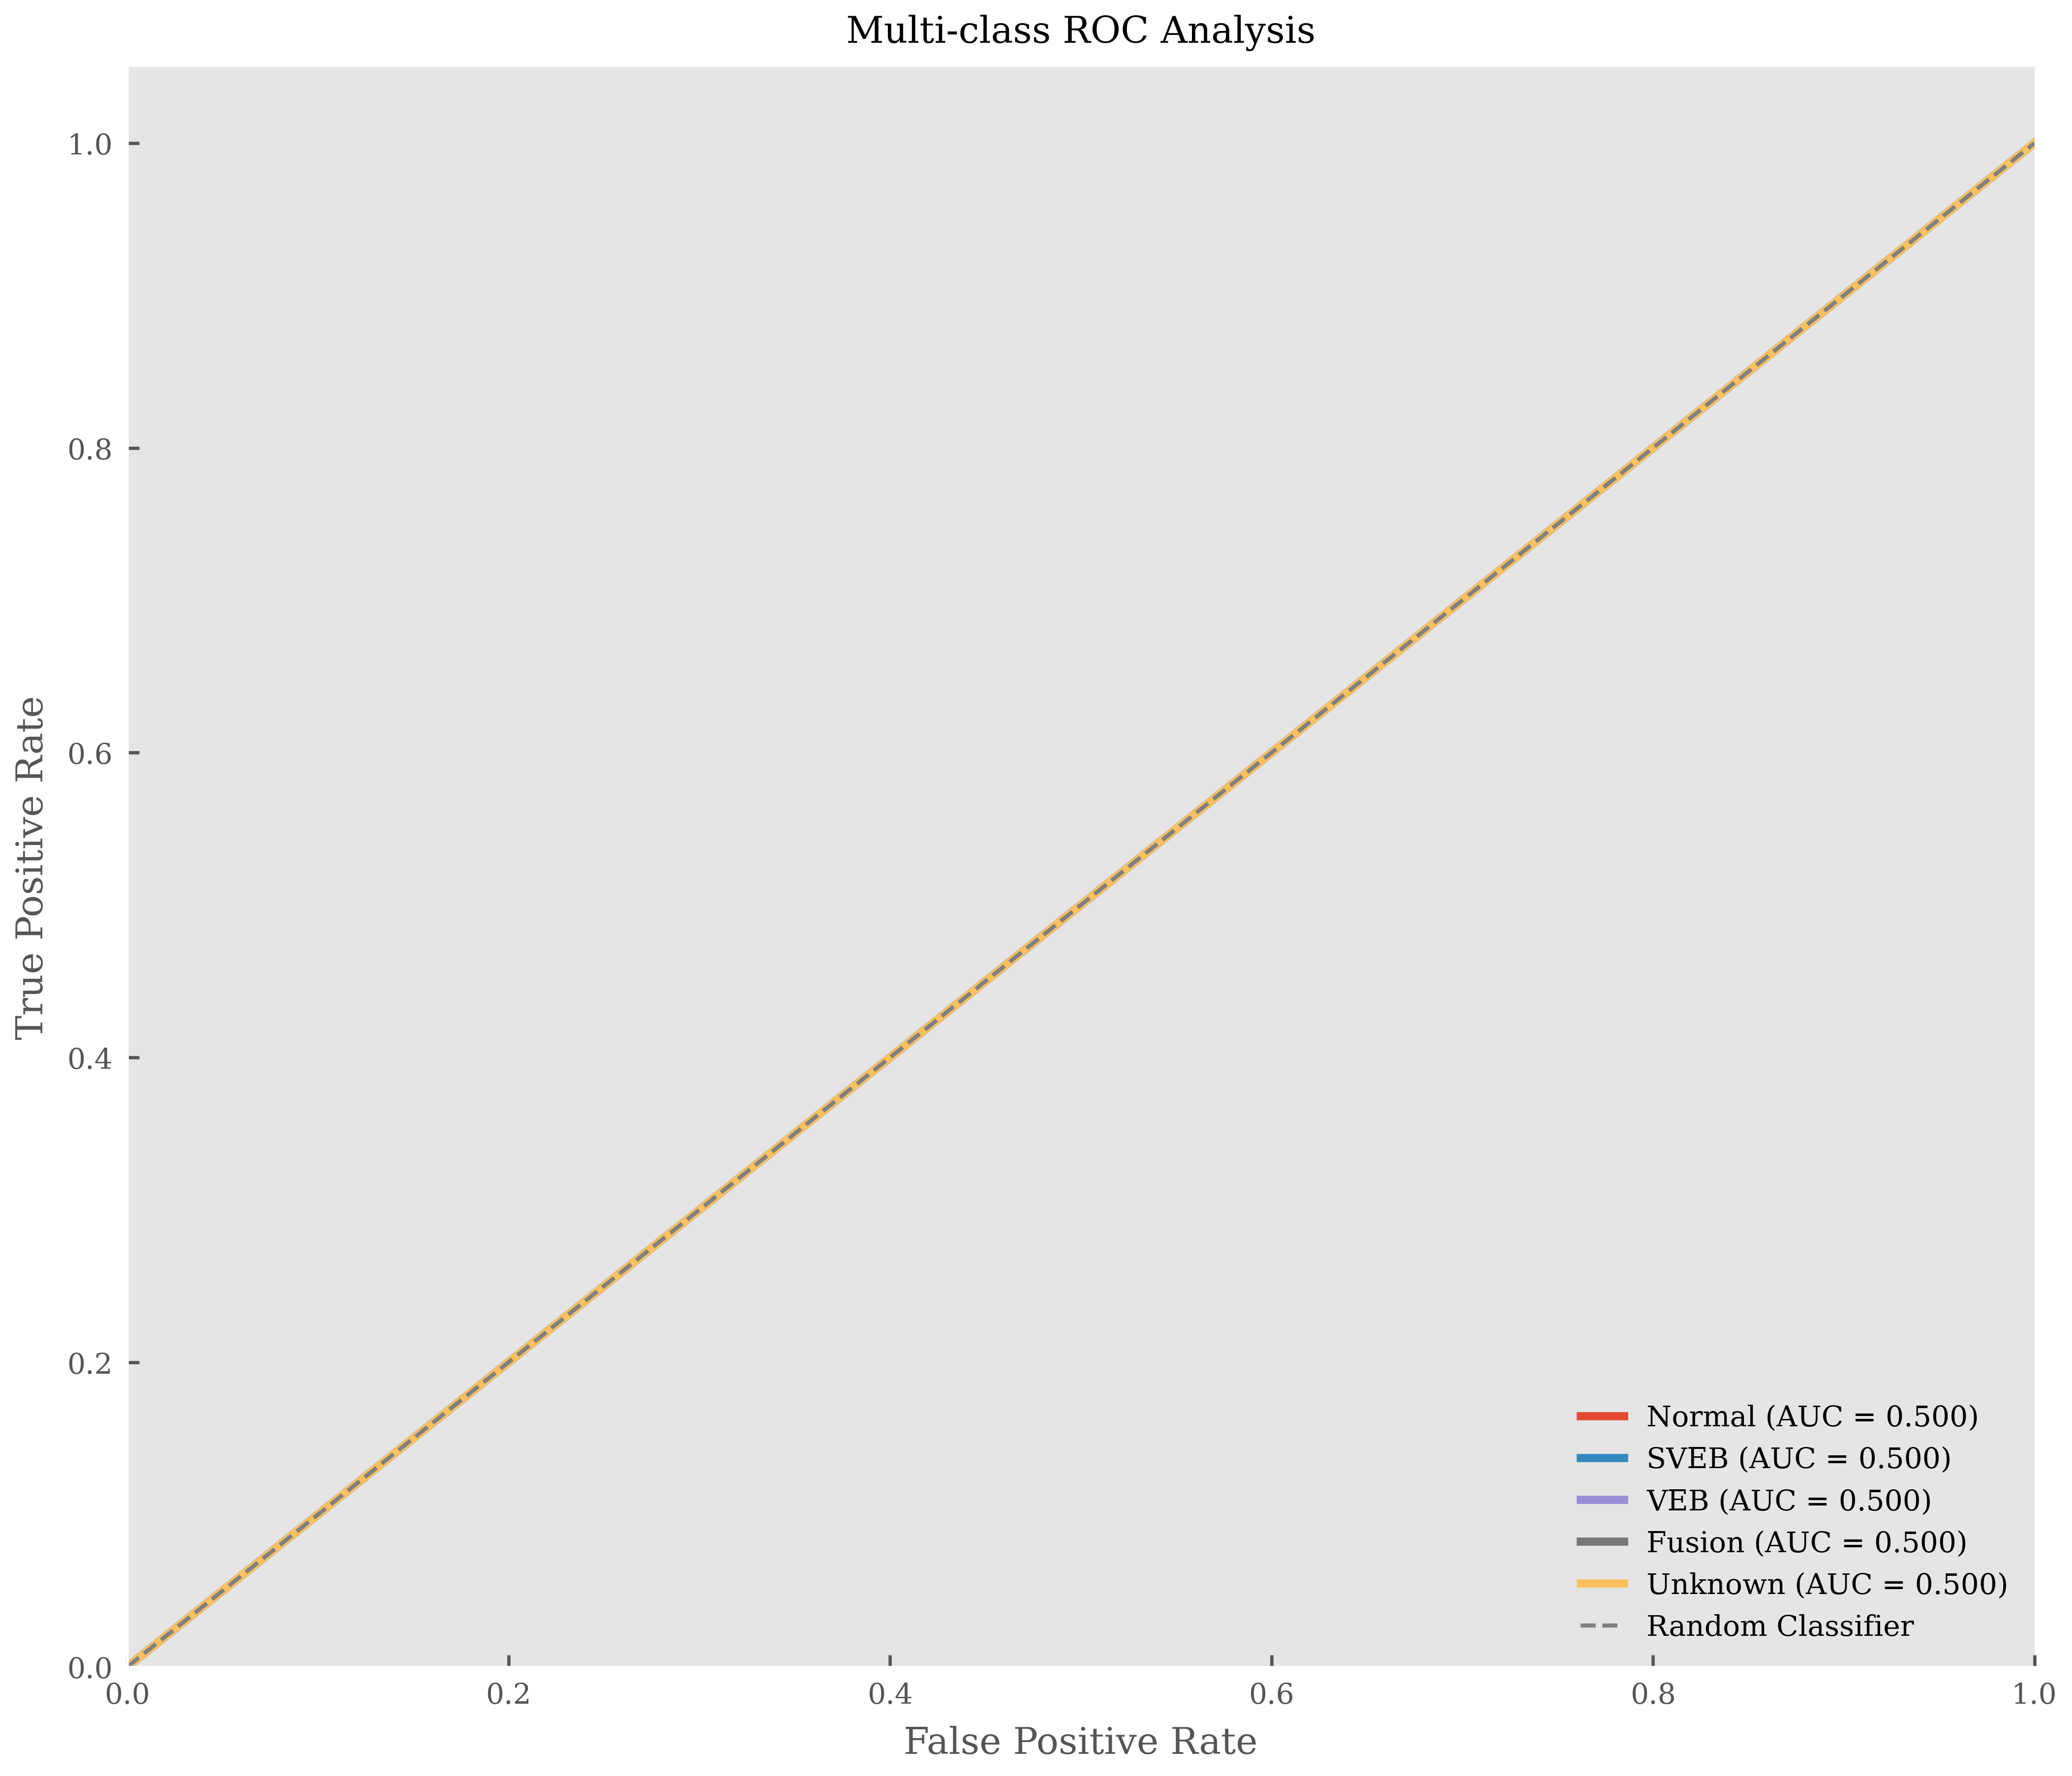

In [18]:
def plot_roc_curves(y_true, y_probs, classes, save_path=RESULTS_DIR / "roc_curves.pdf"):
    plt.figure(figsize=(7, 6))

    for i, class_label in enumerate(classes):
        # Calculate ROC for each class vs all others (One-vs-Rest)
        fpr, tpr, _ = roc_curve(y_true == i, y_probs[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=2, label=f'{class_label} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC Analysis')
    plt.legend(loc="lower right")

    plt.savefig(save_path)
    plt.show()

plot_roc_curves(y_val_raw, y_pred_prob, class_names)

In [19]:
def export_classification_metrics(y_true, y_pred, classes, save_path=RESULTS_DIR / "metrics_report.txt"):
    report = classification_report(y_true, y_pred, target_names=classes)

    # Print to console
    print(" Final Classification Report ")
    print(report)

    # Save to file
    with open(save_path, "w") as f:
        f.write("ECG Classification Research Metrics\n")
        f.write("="*40 + "\n")
        f.write(report)

    print(f"Metrics saved to {save_path}")

export_classification_metrics(y_val_raw, y_pred, class_names)

 Final Classification Report 
              precision    recall  f1-score   support

      Normal       0.83      1.00      0.91     18118
        SVEB       0.00      0.00      0.00       556
         VEB       0.00      0.00      0.00      1448
      Fusion       0.00      0.00      0.00       162
     Unknown       0.00      0.00      0.00      1608

    accuracy                           0.83     21892
   macro avg       0.17      0.20      0.18     21892
weighted avg       0.68      0.83      0.75     21892

Metrics saved to research_output/metrics_report.txt


/home/srirama/sr_proj/tf-venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/srirama/sr_proj/tf-venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/srirama/sr_proj/tf-venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [37]:
model.save_weights(RESULTS_DIR / 'baseline_rnn.weights.h5') 
model.export(RESULTS_DIR / "baseline_rnn")

2026-01-22 16:53:01,456 - INFO - Function `__call__` contains input name(s) resource with unsupported characters which will be renamed to sequential_1_dense_5_1_biasadd_readvariableop_resource in the SavedModel.
2026-01-22 16:53:01,521 - INFO - Function `__call__` contains input name(s) resource with unsupported characters which will be renamed to sequential_1_dense_5_1_biasadd_readvariableop_resource in the SavedModel.
2026-01-22 16:53:02,072 - INFO - Assets written to: research_output/baseline_rnn/assets
Saved artifact at 'research_output/baseline_rnn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 187, 1), dtype=tf.int32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  125395135921232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135920656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135920848: TensorSpec(shape=(), dtype=tf.resource, 

In [44]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False
tflite_float_model = converter.convert()
# Show model size in KBs.
float_model_size = len(tflite_float_model) / 1024

2026-01-22 17:01:32,443 - INFO - Assets written to: /tmp/tmpcxdlqnyu/assets
Saved artifact at '/tmp/tmpcxdlqnyu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 187, 1), dtype=tf.int32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  125395135921232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135920656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135920848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135022480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135022864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135023632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135021136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135022672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135025168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135022096

W0000 00:00:1769101292.677996   49707 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1769101292.678087   49707 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-01-22 17:01:32.678478: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpcxdlqnyu
2026-01-22 17:01:32.679571: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-01-22 17:01:32.679594: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpcxdlqnyu
2026-01-22 17:01:32.696018: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-01-22 17:01:32.770169: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpcxdlqnyu
2026-01-22 17:01:32.800162: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 121688 microseconds.
2026-01-22 17:01:32.980615: W tensorflow/com

In [45]:
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Apply the suggested fix for RNNs and dynamic shapes
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False
tflite_quantized_model = converter.convert()
tflite_path = RESULTS_DIR / "optimized_model.tflite"
quantized_model_size = len(tflite_quantized_model) / 1024

2026-01-22 17:01:37,898 - INFO - Assets written to: /tmp/tmp_eoxk069/assets
Saved artifact at '/tmp/tmp_eoxk069'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 187, 1), dtype=tf.int32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  125395135921232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135920656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135920848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135022480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135022864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135023632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135021136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135022672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135025168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125395135022096

W0000 00:00:1769101298.401603   49707 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1769101298.401665   49707 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-01-22 17:01:38.401862: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp_eoxk069
2026-01-22 17:01:38.402781: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-01-22 17:01:38.402793: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp_eoxk069
2026-01-22 17:01:38.412007: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-01-22 17:01:39.667270: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp_eoxk069
2026-01-22 17:01:39.688448: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 1286588 microseconds.
2026-01-22 17:01:39.838320: W tensorflow/co

In [46]:
print('Float model size = %dKBs.' % float_model_size)
print('Quantized model size = %dKBs,' % quantized_model_size)
print('which is about %d%% of the float model size.'% (quantized_model_size * 100 / float_model_size))

Float model size = 344KBs.
Quantized model size = 102KBs,
which is about 29% of the float model size.


In [47]:
# A helper function to evaluate the TF Lite model using "test" dataset.
def evaluate_tflite_model(tflite_model,X_test,y_test_raw,input_length=187):
    """Evaluate a TF Lite model for Conv1D ECG classification"""

    # Initialize interpreter
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_index = input_details[0]["index"]
    output_index = output_details[0]["index"]

    correct = 0

    for i in range(len(X_test)):
        # Prepare input: (1, 187, 1)
        sample = X_test[i].reshape(1, input_length, 1).astype(np.float32)

        interpreter.set_tensor(input_index, sample)
        interpreter.invoke()

        # Get prediction
        output = interpreter.get_tensor(output_index)
        pred_class = np.argmax(output[0])
        true_class = y_test_raw[i]

        if pred_class == true_class:
            correct += 1

    accuracy = correct / len(X_test)
    return accuracy


float_accuracy = evaluate_tflite_model(tflite_float_model,X_val,y_val_raw,input_length=INPUT_LENGTH)
print(f"Float TFLite model accuracy = {float_accuracy:.4f}")

quantized_accuracy = evaluate_tflite_model(tflite_quantized_model,X_val,y_val_raw,input_length=INPUT_LENGTH)
print(f"Quantized TFLite model accuracy = {quantized_accuracy:.4f}")
print(f"Accuracy drop = {float_accuracy - quantized_accuracy:.4f}")


/home/srirama/sr_proj/tf-venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


RuntimeError: Select TensorFlow op(s), included in the given model, is(are) not supported by this interpreter. Make sure you apply/link the Flex delegate before inference. For the Android, it can be resolved by adding "org.tensorflow:tensorflow-lite-select-tf-ops" dependency. See instructions: https://www.tensorflow.org/lite/guide/ops_selectNode number 1 (FlexTensorListReserve) failed to prepare.

In [ ]:
# Save the quantized model to file to the Downloads directory
f = open(str(RESULTS_DIR / 'baseline_rnn.tflite'), "wb")
f.write(tflite_quantized_model)
f.close()
print('`baseline_rnn.tflite` has been downloaded')

`1dcnn.tflite` has been downloaded


In [41]:
if MLFLOW_ENABLED:
    mlflow.end_run()
    print(f"MLflow run completed | run_name={run_name}")

2026/01/22 16:56:41 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/01/22 16:56:41 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run run2 at: http://localhost:5000/#/experiments/2/runs/085acd7e52694f5e82108f4366c33936
🧪 View experiment at: http://localhost:5000/#/experiments/2
MLflow run completed | run_name=run2
